# Fixed header row + fractional body columns.

## Layout (fig_width='6in', fig_height='3.5in')
---------------------------------------------
```
┌──────────────────────────────────────────┐  ← 0.35in fixed title row
├─────────────────┬────────────────────────┤  ← 1fr body row
│  histogram      │      time series       │
│   (1fr col)     │      (2fr col)         │
└─────────────────┴────────────────────────┘
```
'fr' columns split the available width proportionally: the left panel gets
one third, the right panel gets two thirds.  Because neither body panel
has an aspect constraint, the height comes entirely from fig_height and the
fixed title row — a common pattern for data figures.

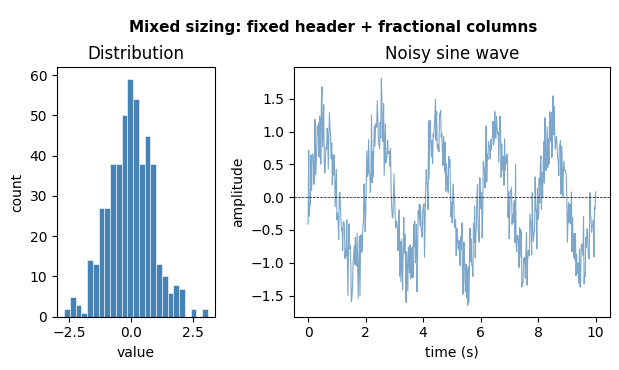

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mplayout import Grid

rng = np.random.default_rng(1)

g = Grid(
    rows=['0.35in', '1fr'],
    cols=['1fr', '2fr'],
    wgap='20mm', hgap='3mm',
)

p_title = g.panel(row=0, col=0, colspan=2)
p_hist  = g.panel(row=1, col=0)
p_ts    = g.panel(row=1, col=1)

fig, axes = g.build(fig_width='6in', fig_height='3.5in')

axes[p_title].axis('off')
axes[p_title].text(0.5, 0.5, 'Mixed sizing: fixed header + fractional columns',
                   ha='center', va='center', fontsize=11, fontweight='bold',
                   transform=axes[p_title].transAxes)

data = rng.standard_normal(500)
axes[p_hist].hist(data, bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
axes[p_hist].set_xlabel('value')
axes[p_hist].set_ylabel('count')
axes[p_hist].set_title('Distribution')

t = np.linspace(0, 10, 500)
signal = np.sin(2 * np.pi * 0.5 * t) + 0.3 * rng.standard_normal(500)
axes[p_ts].plot(t, signal, color='steelblue', linewidth=0.8, alpha=0.7)
axes[p_ts].axhline(0, color='k', linewidth=0.5, linestyle='--')
axes[p_ts].set_xlabel('time (s)')
axes[p_ts].set_ylabel('amplitude')
axes[p_ts].set_title('Noisy sine wave')

plt.show()